# AIPI 510: Module 1 Project: Data Storytelling
### - notebooks/final_visualizations.ipynb
### Hasan Al-Quaid

# Final visualization for: 2024 NHTSA Data

# Title: How will You Die On Your Motorcycle?

In [1]:
# importing libararies
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
import seaborn as sns

In [2]:
%matplotlib inline

In [3]:
# Load in the processed data
final_motorcycles_df = pd.read_csv("../data/processed/final_motorcycles.csv")
print(final_motorcycles_df.shape)

(6901, 310)


C:\Users\hasan\AppData\Local\Temp\ipykernel_15508\3883263224.py:2: DtypeWarning: Columns (17,45,219) have mixed types. Specify dtype option on import or set low_memory=False.
  final_motorcycles_df = pd.read_csv("../data/processed/final_motorcycles.csv")


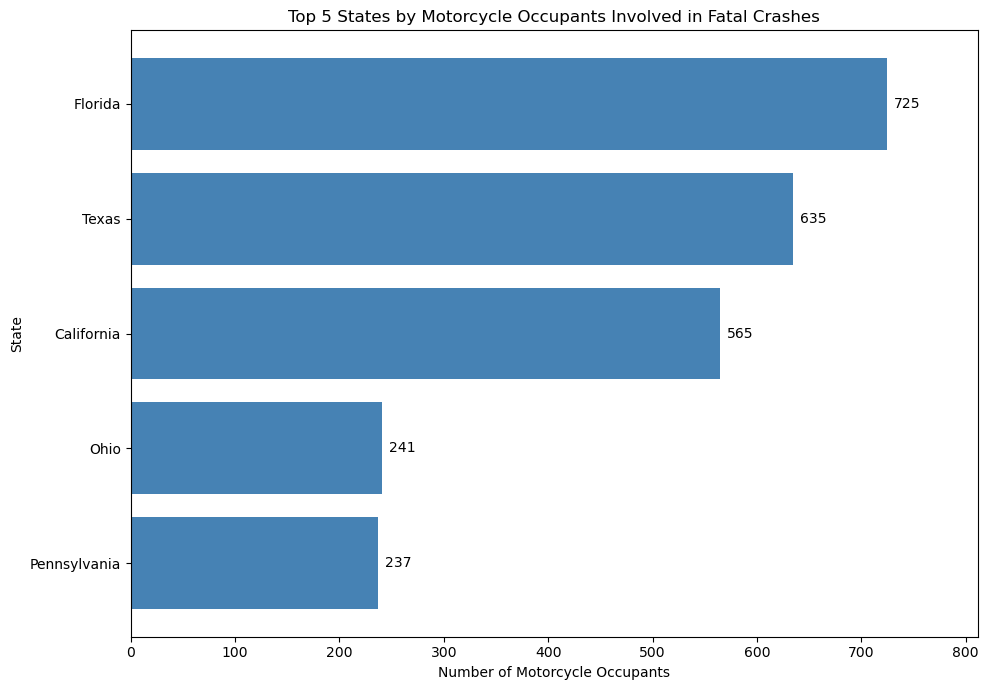

In [4]:
# Top five states by motorcycle occupant count in fatal crashes
state_counts = final_motorcycles_df["STATENAME_x"].value_counts().head(5)

plt.figure(figsize=(10, 7))

bars = plt.barh(state_counts.index, state_counts.values, color="steelblue")
plt.bar_label(bars, fmt="%.0f", padding=5)

plt.title("Top 5 States by Motorcycle Occupants Involved in Fatal Crashes")
plt.xlabel("Number of Motorcycle Occupants")
plt.ylabel("State")
plt.gca().invert_yaxis()
plt.margins(x=0.12)
plt.tight_layout()
plt.show()

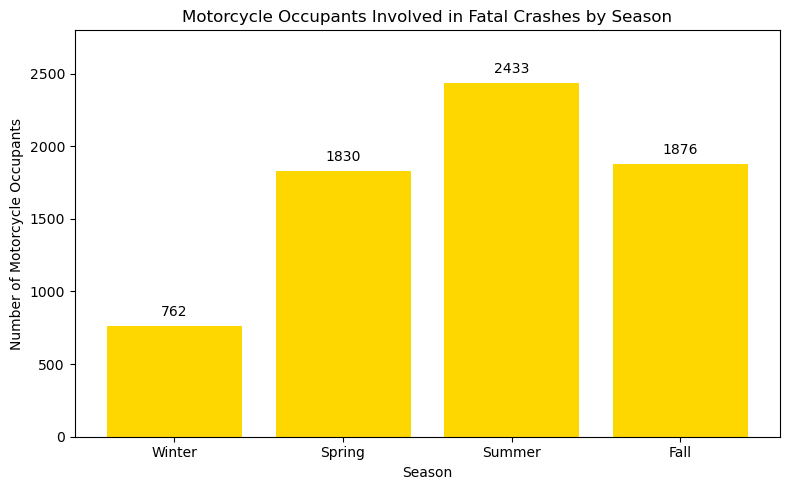

In [5]:
# Motorcycle occupant counts by season
season_order = ["Winter", "Spring", "Summer", "Fall"]
season_counts = final_motorcycles_df["SEASON"].value_counts().reindex(season_order, fill_value=0)

plt.figure(figsize=(8, 5))

bars = plt.bar(season_counts.index, season_counts.values, color="gold")
plt.bar_label(bars, fmt="%.0f", padding=5)

plt.title("Motorcycle Occupants Involved in Fatal Crashes by Season")
plt.xlabel("Season")
plt.ylabel("Number of Motorcycle Occupants")
plt.margins(y=0.15)
plt.tight_layout()
plt.show()

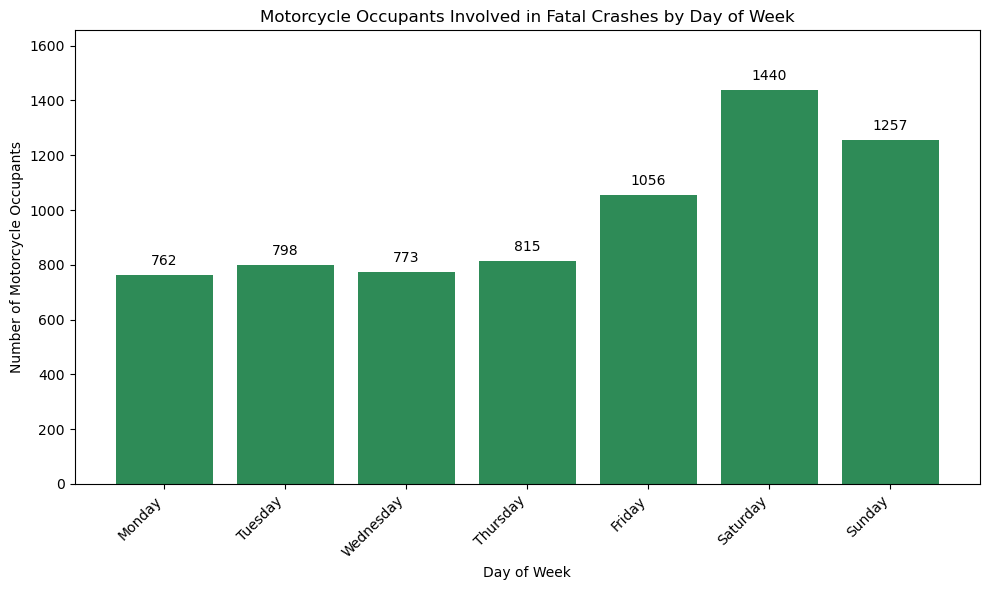

In [6]:
# Motorcycle occupant counts by day of week
week_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
days = final_motorcycles_df["DAY_WEEKNAME"].value_counts().reindex(week_order, fill_value=0)

plt.figure(figsize=(10, 6))

bars = plt.bar(days.index, days.values, color="seagreen")
plt.bar_label(bars, fmt="%.0f", padding=5)

plt.title("Motorcycle Occupants Involved in Fatal Crashes by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Motorcycle Occupants")
plt.xticks(rotation=45, ha="right")
plt.margins(y=0.15)
plt.tight_layout()
plt.show()

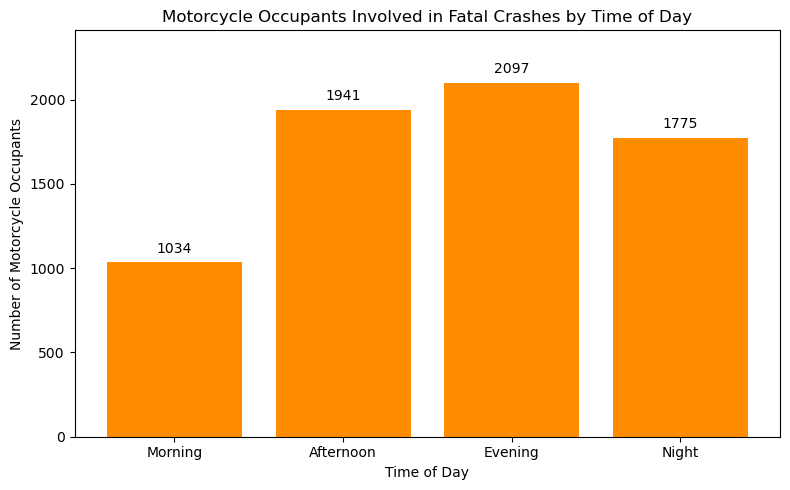

In [7]:
# Motorcycle occupant counts by time of day
time_order = ["Morning", "Afternoon", "Evening", "Night"]
time_counts = final_motorcycles_df["TIME_PERIOD"].value_counts().reindex(time_order, fill_value=0)

plt.figure(figsize=(8, 5))

bars = plt.bar(time_counts.index, time_counts.values, color="darkorange")
plt.bar_label(bars, fmt="%.0f", padding=5)

plt.title("Motorcycle Occupants Involved in Fatal Crashes by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Number of Motorcycle Occupants")
plt.margins(y=0.15)
plt.tight_layout()
plt.show()

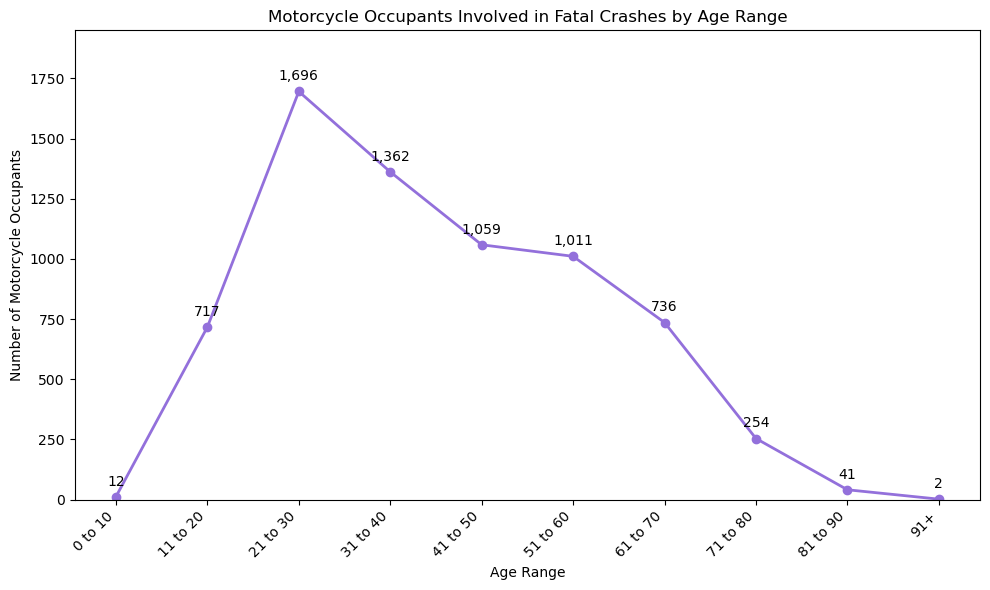

In [8]:
# Motorcycle occupant counts by age range
age_order = ["0 to 10", "11 to 20", "21 to 30", "31 to 40", "41 to 50", "51 to 60", "61 to 70", "71 to 80", "81 to 90", "91+"]
age_counts = final_motorcycles_df["AGE_RANGE"].value_counts().reindex(age_order, fill_value=0)

plt.figure(figsize=(10, 6))

plt.plot(age_counts.index, age_counts.values, marker="o", color="mediumpurple", linewidth=2)

for age_range, count in age_counts.items():
    plt.annotate(f"{count:,.0f}", (age_range, count), textcoords="offset points", xytext=(0, 8), ha="center")

plt.title("Motorcycle Occupants Involved in Fatal Crashes by Age Range")
plt.xlabel("Age Range")
plt.ylabel("Number of Motorcycle Occupants")
plt.xticks(rotation=45, ha="right")
plt.margins(y=0.15)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

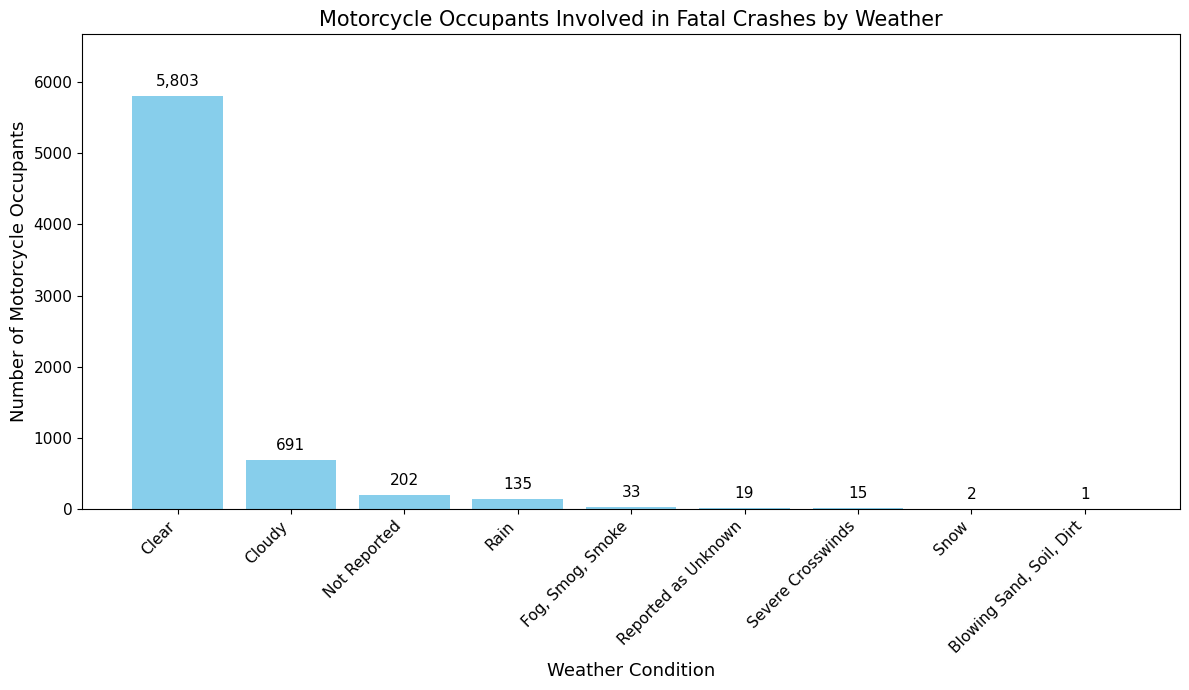

In [9]:
# Motorcycle occupant counts by weather condition
weather_counts = final_motorcycles_df["WEATHERNAME"].value_counts()

plt.figure(figsize=(12, 7))

bars = plt.bar(weather_counts.index, weather_counts.values, color="skyblue")
plt.bar_label(bars, labels=[f"{count:,}" for count in weather_counts.values], padding=5, fontsize=11)

plt.title("Motorcycle Occupants Involved in Fatal Crashes by Weather", fontsize=15)
plt.xlabel("Weather Condition", fontsize=13)
plt.ylabel("Number of Motorcycle Occupants", fontsize=13)
plt.xticks(rotation=45, ha="right", fontsize=11)
plt.yticks(fontsize=11)
plt.margins(y=0.15)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

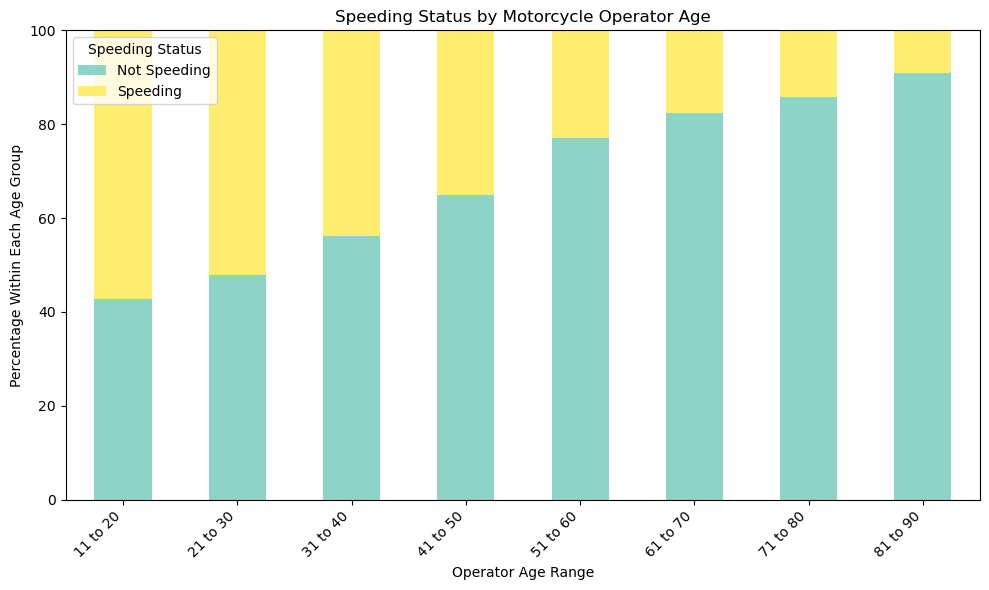

In [17]:
# Operator age and speeding
motorcycle_operators = final_motorcycles_df.loc[final_motorcycles_df["PER_TYP"].eq(1)].copy()
age_range_speeding_percentages = pd.crosstab(motorcycle_operators["AGE_RANGE"], motorcycle_operators["SPEEDING"], normalize="index").mul(100).round(1)

age_plot = age_range_speeding_percentages.drop(index=["0 to 10", "91+", "Unknown"], errors="ignore")
age_plot = age_plot.rename(columns={False: "Not Speeding", True: "Speeding"})

age_plot.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="Set3")

plt.title("Speeding Status by Motorcycle Operator Age")
plt.xlabel("Operator Age Range")
plt.ylabel("Percentage Within Each Age Group")
plt.ylim(0, 100)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Speeding Status")
plt.tight_layout()
plt.show()

##### Among motorcycle operators in fatal crashes with known speeding status. Ages 0–10 (n=1), 91+ (n=2), and unknown ages (n=8) are omitted. The 81–90 group contains 33 operators.

# Surprising Information:

In [22]:
young_operator = motorcycle_operators.loc[motorcycle_operators["AGE_RANGE"].eq("0 to 10")]

display(young_operator[["ST_CASE", "VEH_NO", "PER_NO", "AGE", "AGE_RANGE", "PER_TYP", "PER_TYPNAME", "SPEEDING"]])

,ST_CASE,VEH_NO,PER_NO,AGE,AGE_RANGE,PER_TYP,PER_TYPNAME,SPEEDING
1156,80440,1,1.0,9.0,0 to 10,1.0,Driver of a Motor Vehicle In-Transport,False


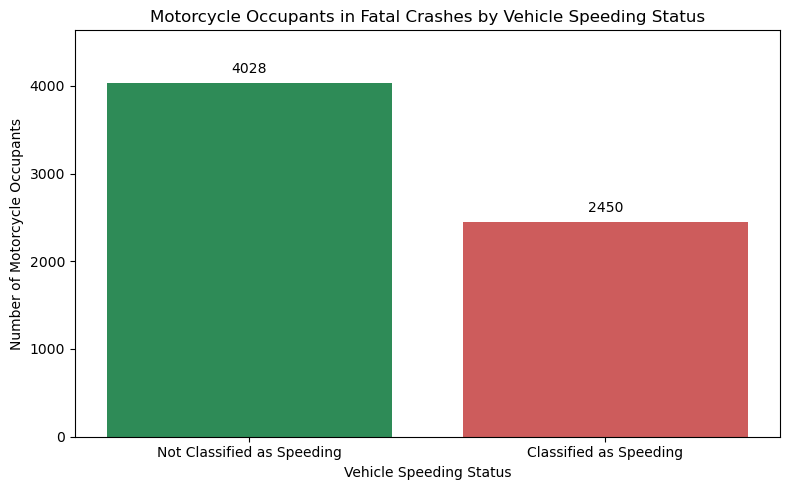

In [11]:
# Motorcycle occupant counts by vehicle speeding status
speeding_counts = final_motorcycles_df["SPEEDING"].value_counts().reindex([False, True], fill_value=0)
speeding_counts.index = ["Not Classified as Speeding", "Classified as Speeding"]

plt.figure(figsize=(8, 5))

bars = plt.bar(speeding_counts.index, speeding_counts.values, color=["seagreen", "indianred"])
plt.bar_label(bars, fmt="%.0f", padding=5)

plt.title("Motorcycle Occupants in Fatal Crashes by Vehicle Speeding Status")
plt.xlabel("Vehicle Speeding Status")
plt.ylabel("Number of Motorcycle Occupants")
plt.margins(y=0.15)
plt.tight_layout()
plt.show()

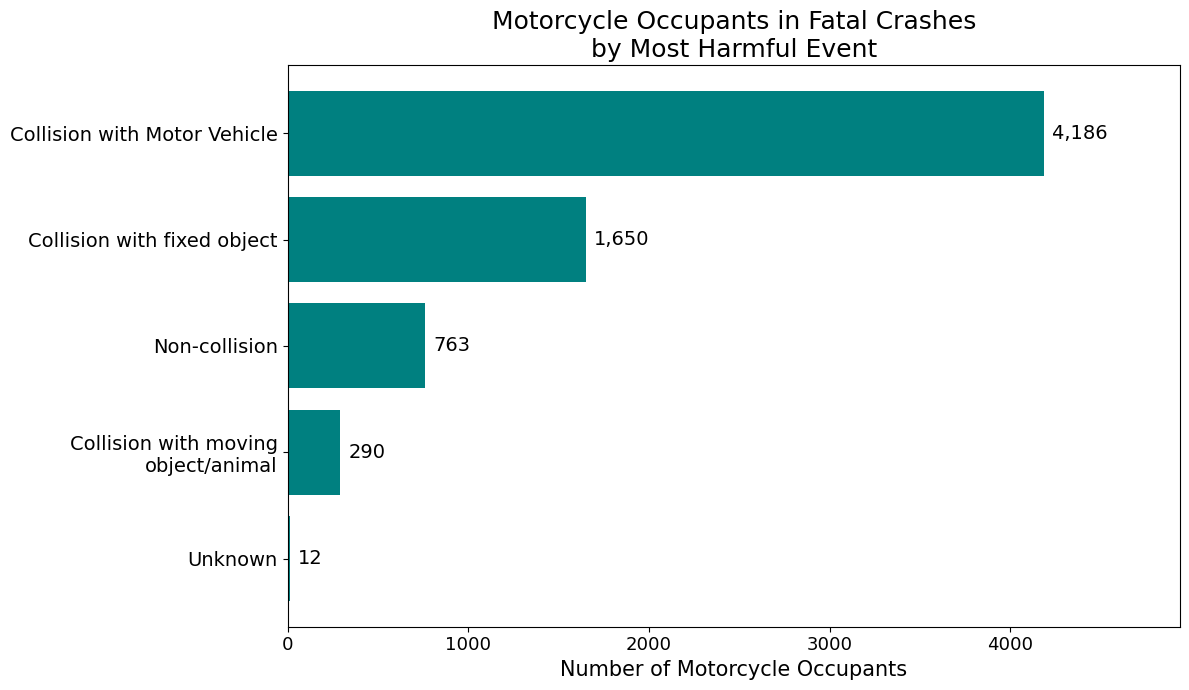

In [12]:
harm_counts = final_motorcycles_df["MOST_HARMFUL_EVENT"].value_counts()
harm_labels = [textwrap.fill(str(label), width=30) for label in harm_counts.index]

plt.figure(figsize=(12, 7))

bars = plt.barh(harm_labels, harm_counts.values, color="teal")
plt.bar_label(bars, labels=[f"{count:,}" for count in harm_counts.values], padding=6, fontsize=14)

plt.title("Motorcycle Occupants in Fatal Crashes\nby Most Harmful Event", fontsize=18)
plt.xlabel("Number of Motorcycle Occupants", fontsize=15)
plt.xticks(fontsize=13)
plt.yticks(fontsize=14)
plt.gca().invert_yaxis()
plt.margins(x=0.18)
plt.xlim(left=0)
plt.tight_layout()
plt.show()

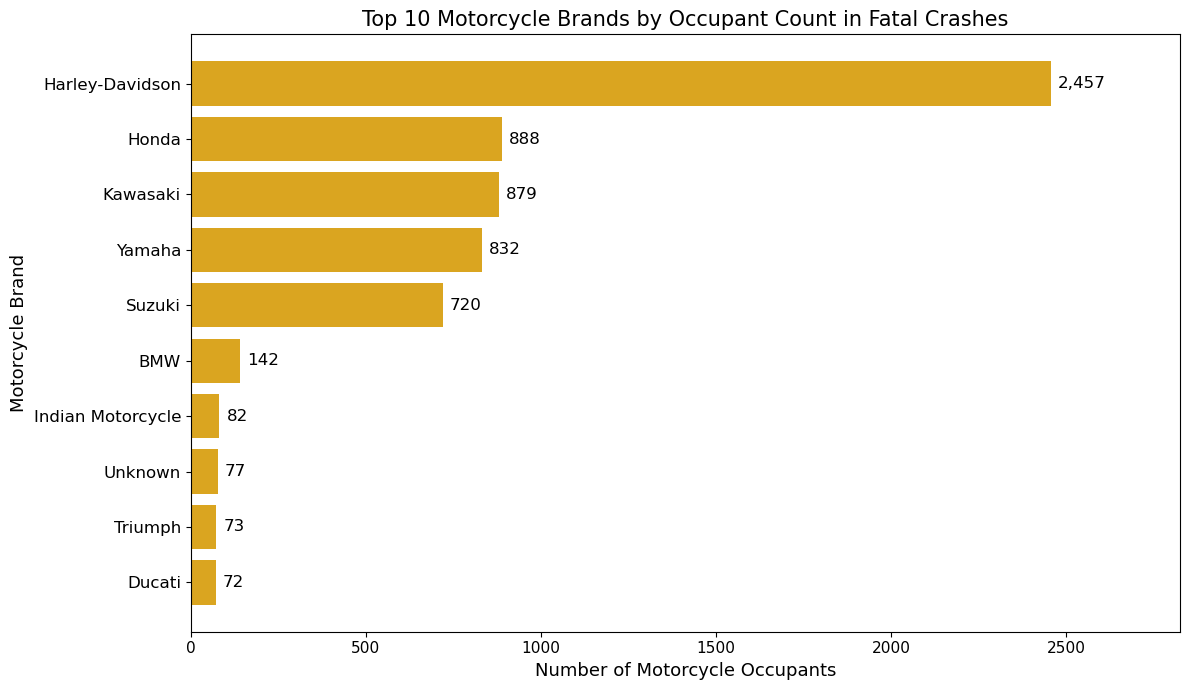

In [13]:
# Top 10 motorcycle brands by occupant count
make_counts = final_motorcycles_df["VPICMAKENAME_x"].value_counts().head(10)

plt.figure(figsize=(12, 7))

bars = plt.barh(make_counts.index, make_counts.values, color="goldenrod")
plt.bar_label(bars, labels=[f"{count:,}" for count in make_counts.values], padding=5, fontsize=12)

plt.title("Top 10 Motorcycle Brands by Occupant Count in Fatal Crashes", fontsize=15)
plt.xlabel("Number of Motorcycle Occupants", fontsize=13)
plt.ylabel("Motorcycle Brand", fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=12)
plt.gca().invert_yaxis()
plt.margins(x=0.15)
plt.xlim(left=0)
plt.tight_layout()
plt.show()

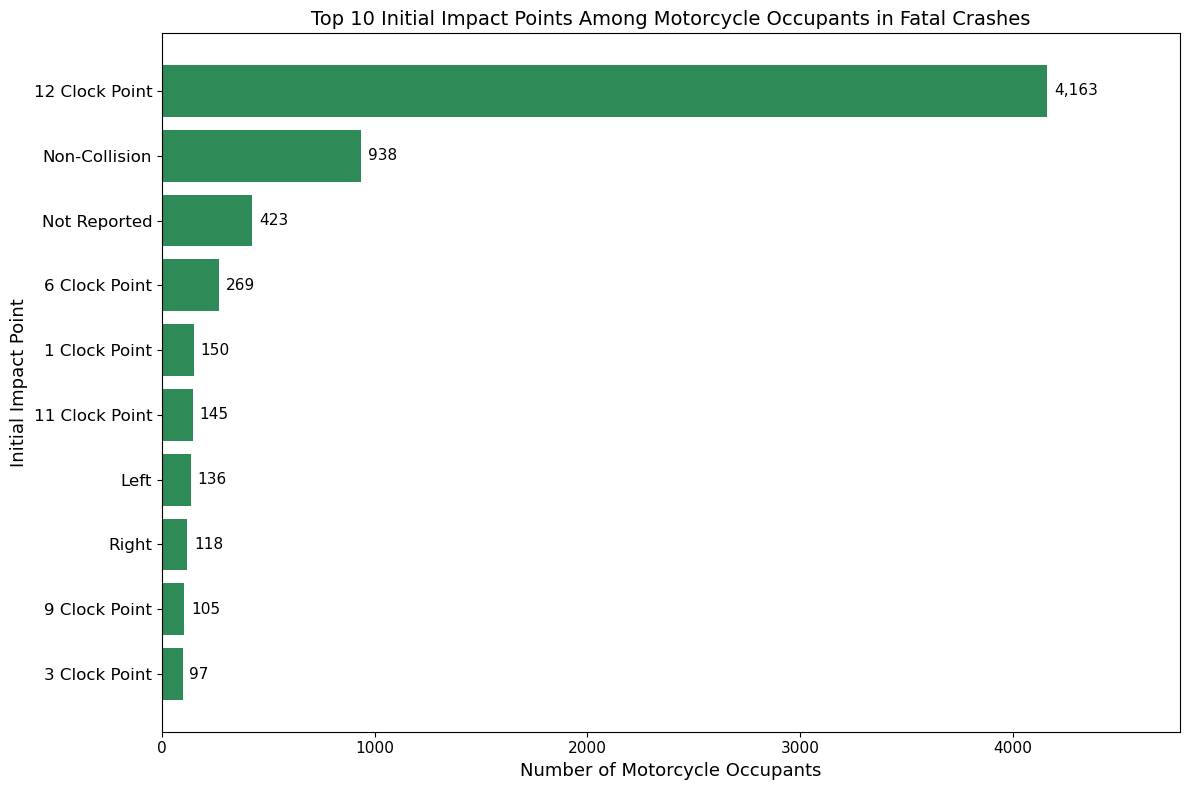

In [14]:
# Top 10 initial impact points by motorcycle occupant count
impact_counts = final_motorcycles_df["IMPACT1NAME_x"].value_counts().head(10)

plt.figure(figsize=(12, 8))

bars = plt.barh(impact_counts.index, impact_counts.values, color="seagreen")
plt.bar_label(bars, labels=[f"{count:,}" for count in impact_counts.values], padding=5, fontsize=11)

plt.title("Top 10 Initial Impact Points Among Motorcycle Occupants in Fatal Crashes", fontsize=14)
plt.xlabel("Number of Motorcycle Occupants", fontsize=13)
plt.ylabel("Initial Impact Point", fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=12)
plt.gca().invert_yaxis()
plt.margins(x=0.15)
plt.xlim(left=0)
plt.tight_layout()
plt.show()

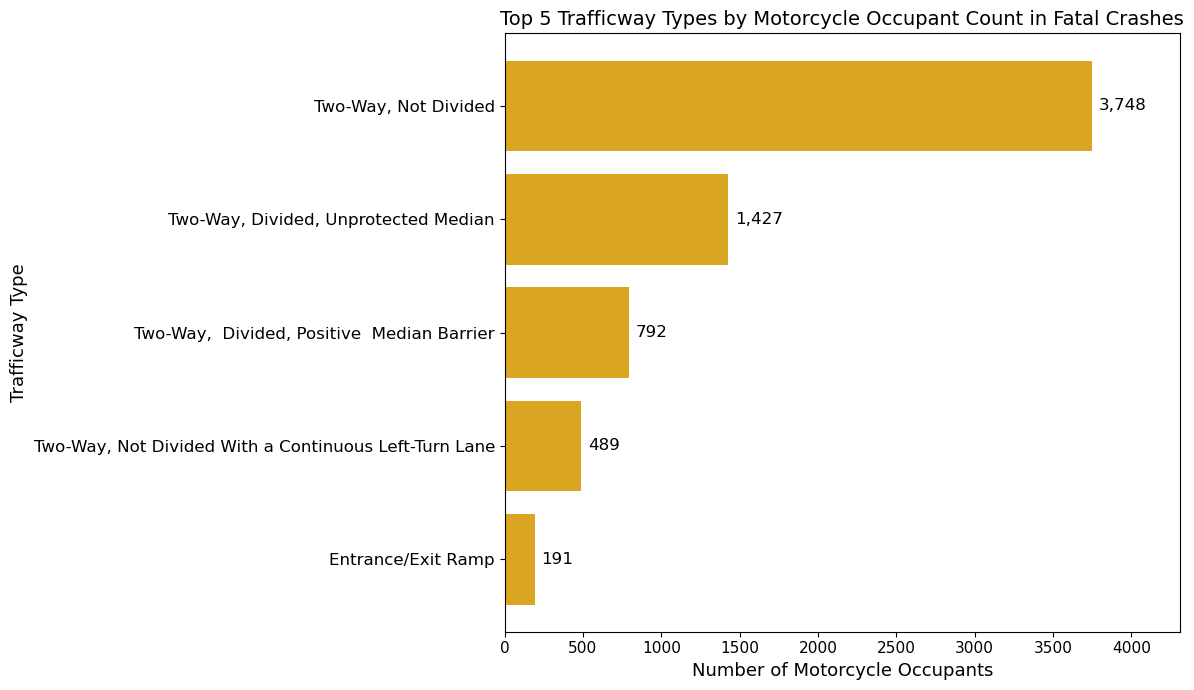

In [15]:
# Top 5 trafficway types by motorcycle occupant count
vtraf_counts = final_motorcycles_df["VTRAFWAYNAME"].value_counts().head(5)

plt.figure(figsize=(12, 7))

bars = plt.barh(vtraf_counts.index, vtraf_counts.values, color="goldenrod")
plt.bar_label(bars, labels=[f"{count:,}" for count in vtraf_counts.values], padding=5, fontsize=12)

plt.title("Top 5 Trafficway Types by Motorcycle Occupant Count in Fatal Crashes", fontsize=14)
plt.xlabel("Number of Motorcycle Occupants", fontsize=13)
plt.ylabel("Trafficway Type", fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=12)
plt.gca().invert_yaxis()
plt.margins(x=0.15)
plt.xlim(left=0)
plt.tight_layout()
plt.show()

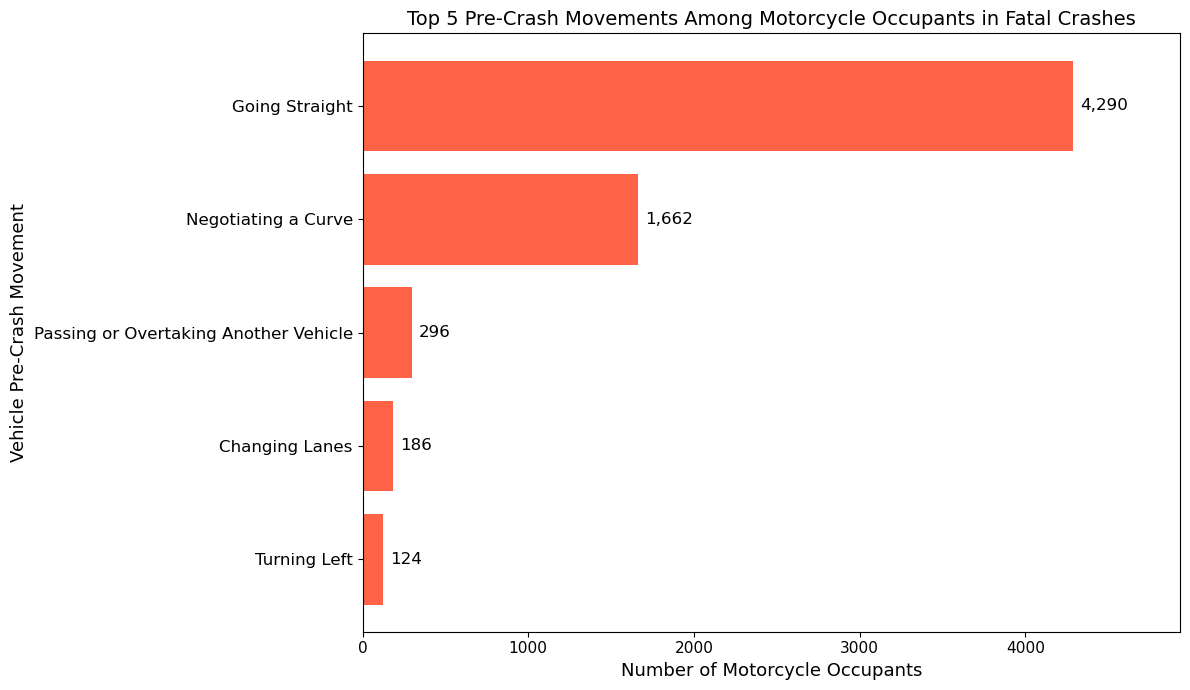

In [16]:
# Top 5 vehicle pre-crash movements by motorcycle occupant count
precrash_counts = final_motorcycles_df["P_CRASH1NAME"].value_counts().head(5)

plt.figure(figsize=(12, 7))

bars = plt.barh(precrash_counts.index, precrash_counts.values, color="tomato")
plt.bar_label(bars, labels=[f"{count:,}" for count in precrash_counts.values], padding=5, fontsize=12)

plt.title("Top 5 Pre-Crash Movements Among Motorcycle Occupants in Fatal Crashes", fontsize=14)
plt.xlabel("Number of Motorcycle Occupants", fontsize=13)
plt.ylabel("Vehicle Pre-Crash Movement", fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=12)
plt.gca().invert_yaxis()
plt.margins(x=0.15)
plt.xlim(left=0)
plt.tight_layout()
plt.show()